In [14]:
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split


In [15]:
data = pd.read_csv("Iris.csv",index_col="Id")

data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


<Axes: xlabel='Id', ylabel='PetalWidthCm'>

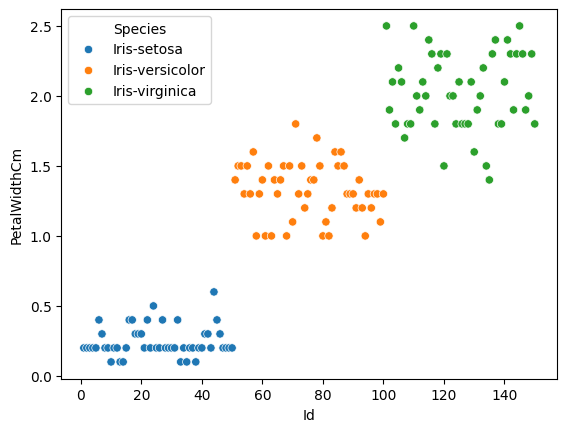

In [16]:
sns.scatterplot(
    y="PetalWidthCm",
    x="Id",
    hue="Species",
    data=data
)

<Axes: xlabel='SepalWidthCm', ylabel='Id'>

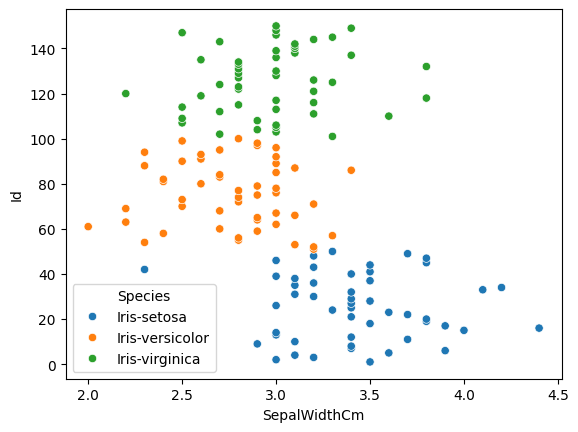

In [17]:
sns.scatterplot(
    x="SepalWidthCm",
    y="Id",
    hue="Species",
    data=data
)

<Axes: xlabel='SepalWidthCm', ylabel='PetalWidthCm'>

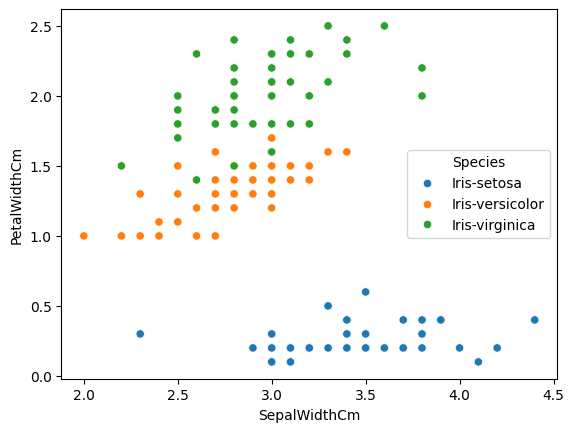

In [18]:
sns.scatterplot(
    x="SepalWidthCm",
    y="PetalWidthCm",
    hue="Species",
    data=data
)

In [19]:
#weon  estan tan diferentes que se pueden diferenciar facilmente con simpmente estos valores esta demaciado marcado

In [20]:
from sklearn.preprocessing import LabelEncoder
econd = LabelEncoder()
endata = econd.fit_transform(data["Species"])
data["endata"] = endata
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,endata
Id,,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa,0
2,4.9,3.0,1.4,0.2,Iris-setosa,0
3,4.7,3.2,1.3,0.2,Iris-setosa,0
4,4.6,3.1,1.5,0.2,Iris-setosa,0
5,5.0,3.6,1.4,0.2,Iris-setosa,0
...,...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica,2
147,6.3,2.5,5.0,1.9,Iris-virginica,2
148,6.5,3.0,5.2,2.0,Iris-virginica,2


In [21]:
data = data.drop(columns="Species")

In [22]:
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,endata
Id,,,,,
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0
5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,2
147,6.3,2.5,5.0,1.9,2
148,6.5,3.0,5.2,2.0,2


C:\Users\emman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\emman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\emman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\emman\AppData\Local\Packages\Py

<Axes: xlabel='SepalWidthCm', ylabel='endata'>

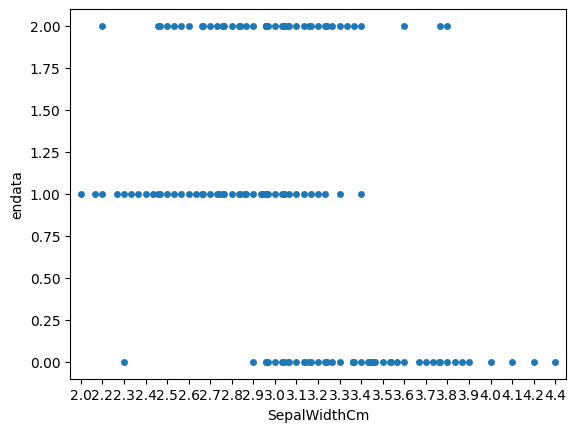

In [23]:
sns.swarmplot(
    data=data,
    x="SepalWidthCm",
    y="endata"
    )

In [24]:
#no ayuda es demaciado marcdo  se no a simple fista la diferencia de los 3 el modelo no deberia tener problemas 

In [25]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]
y

Id
1      0
2      0
3      0
4      0
5      0
      ..
146    2
147    2
148    2
149    2
150    2
Name: endata, Length: 150, dtype: int64

In [26]:
x_entrenamiento,x_val,y_entrenamiento,y_val = train_test_split(x,y,test_size=0.2,random_state=0)

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=50,
    max_depth=6,
    n_jobs=-1
    
)
model.fit(x_entrenamiento, y_entrenamiento)
pred = model.predict(x_val)
print(classification_report(y_val,pred))




              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

